In [27]:
import pandas as pd

In [28]:
df = pd.read_csv("Customers_Cleaned.csv")
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance_Highsalary_Flag,Product_Engagement_Score
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,3
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,2
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,4
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,2
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,3


In [29]:
print(df.columns)

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'ZeroBalance_Highsalary_Flag',
       'Product_Engagement_Score'],
      dtype='object')


In [30]:
# Load your transaction dataset
transactions = pd.read_csv("transactions.csv")

# Calculate transaction frequency and average transaction amount per customer
txn_summary = transactions.groupby('CustomerId').agg(
    Transaction_Frequency=('Transaction_ID', 'count'),
    Avg_Transaction_Amount=('Amount', 'mean')
).reset_index()

# Merge with your churn modelling data
df = df.merge(txn_summary, on='CustomerId', how='left')

df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance_Highsalary_Flag,Product_Engagement_Score,Transaction_Frequency,Avg_Transaction_Amount
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,3,11,2371.399091
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,2,16,2635.160625
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0,4,11,2663.665455
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,2,18,2227.861667
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,3,14,2745.462143


In [31]:
df.groupby('Geography')['Transaction_Frequency'].mean().sort_values(ascending=False)

Geography
France     12.087727
Spain      12.070198
Germany    12.067540
Name: Transaction_Frequency, dtype: float64

In [32]:
df[['Transaction_Frequency', 'Avg_Transaction_Amount']].describe()

,Transaction_Frequency,Avg_Transaction_Amount
count,9678.000000,9678.000000
mean,12.078322,2521.306961
std,4.292964,439.962199
min,5.000000,441.590000
25%,8.000000,2235.262761
50%,12.000000,2522.626526
75%,16.000000,2809.093833
max,19.000000,4476.724000


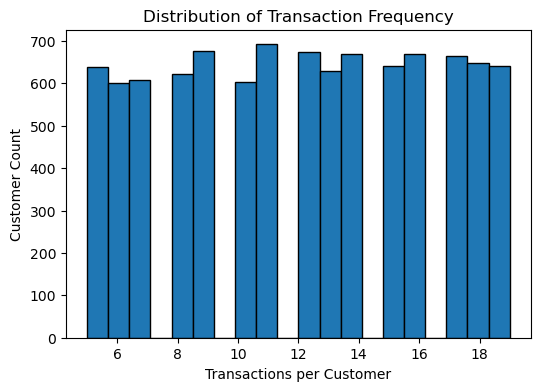

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Transaction_Frequency'], bins=20, edgecolor='black')
plt.title('Distribution of Transaction Frequency')
plt.xlabel('Transactions per Customer')
plt.ylabel('Customer Count')
plt.show()


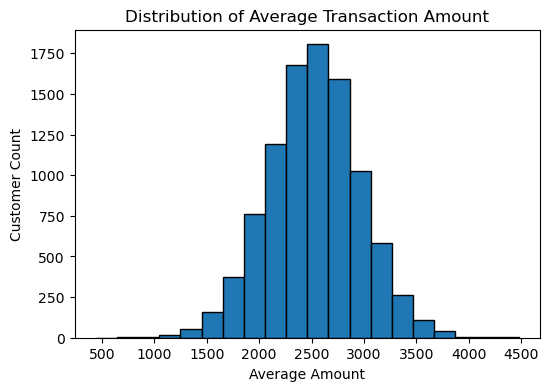

In [34]:
plt.figure(figsize=(6,4))
plt.hist(df['Avg_Transaction_Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Average Transaction Amount')
plt.xlabel('Average Amount')
plt.ylabel('Customer Count')
plt.show()


In [35]:
df.groupby('Geography')[['Transaction_Frequency', 'Avg_Transaction_Amount']].mean().sort_values('Transaction_Frequency', ascending=False)


,Transaction_Frequency,Avg_Transaction_Amount
Geography,,
France,12.087727,2525.290772
Spain,12.070198,2520.591725
Germany,12.067540,2514.084760


In [36]:
df.groupby('Exited')[['Transaction_Frequency', 'Avg_Transaction_Amount']].mean()

,Transaction_Frequency,Avg_Transaction_Amount
Exited,,
0,12.085714,2520.304984
1,12.050174,2525.122241


In [37]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                        labels=['<25','25-35','35-45','45-55','55-65','65+'])
df.groupby('AgeGroup')[['Transaction_Frequency', 'Avg_Transaction_Amount']].mean()


C:\Users\HP\AppData\Local\Temp\ipykernel_16264\3462234245.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')[['Transaction_Frequency', 'Avg_Transaction_Amount']].mean()


,Transaction_Frequency,Avg_Transaction_Amount
AgeGroup,,
<25,11.996835,2488.202076
25-35,12.137980,2527.494714
35-45,12.106799,2514.926566
45-55,11.914569,2535.442084
55-65,11.904851,2511.301615
65+,12.143939,2518.958746


In [38]:
customers = pd.read_csv("Customers_Cleaned.csv")
transactions = pd.read_csv("transactions.csv")

missing_customers = customers[~customers['CustomerId'].isin(transactions['CustomerId'])]
print("Customers without transactions:", len(missing_customers))
print(missing_customers[['CustomerId', 'Age', 'Geography']].head())


Customers without transactions: 0
Empty DataFrame
Columns: [CustomerId, Age, Geography]
Index: []


In [39]:
df['AgeGroup'].value_counts(dropna=False)

AgeGroup
35-45    3736
25-35    3515
45-55    1311
55-65     536
<25       316
65+       264
Name: count, dtype: int64

In [40]:
print(df['Age'].dtype)
print("Min Age:", df['Age'].min())
print("Max Age:", df['Age'].max())

int64
Min Age: 19
Max Age: 92


In [41]:
df[['Transaction_Frequency', 'Avg_Transaction_Amount', 'Balance', 'Exited']].corr()

,Transaction_Frequency,Avg_Transaction_Amount,Balance,Exited
Transaction_Frequency,1.000000,0.003978,-0.007367,-0.003360
Avg_Transaction_Amount,0.003978,1.000000,-0.007874,0.004444
Balance,-0.007367,-0.007874,1.000000,0.119817
Exited,-0.003360,0.004444,0.119817,1.000000


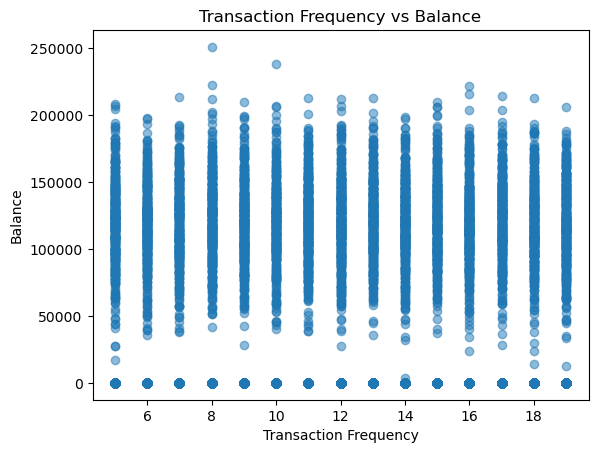

In [42]:
plt.scatter(df['Transaction_Frequency'], df['Balance'], alpha=0.5)
plt.title('Transaction Frequency vs Balance')
plt.xlabel('Transaction Frequency')
plt.ylabel('Balance')
plt.show()

In [43]:
import numpy as np

df['HasTransactions'] = np.where(df['Transaction_Frequency'] > 0, 1, 0)
df.groupby('AgeGroup')['HasTransactions'].mean() * 100


C:\Users\HP\AppData\Local\Temp\ipykernel_16264\3666251129.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['HasTransactions'].mean() * 100


AgeGroup
<25      100.0
25-35    100.0
35-45    100.0
45-55    100.0
55-65    100.0
65+      100.0
Name: HasTransactions, dtype: float64

In [44]:
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.282988
2    0.077201
3    0.828244
4    1.000000
Name: Exited, dtype: float64

In [45]:
df.groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.274472
1    0.145520
Name: Exited, dtype: float64

In [46]:
df.groupby('Tenure')['Exited'].mean()

Tenure
0     0.230024
1     0.224806
2     0.192898
3     0.213213
4     0.207003
5     0.208669
6     0.205757
7     0.175926
8     0.202717
9     0.224622
10    0.224771
Name: Exited, dtype: float64

<Axes: xlabel='CreditScore'>

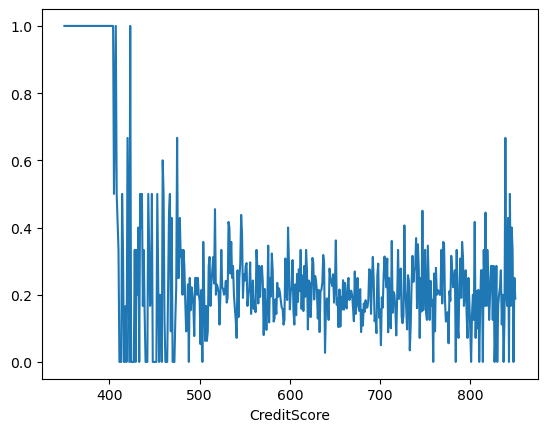

In [47]:
df.groupby('CreditScore')['Exited'].mean().plot()

In [48]:
df.groupby('NumOfProducts')['Exited'].mean().apply(lambda x: round(x*100,2))

NumOfProducts
1     28.30
2      7.72
3     82.82
4    100.00
Name: Exited, dtype: float64

In [49]:
df.groupby('IsActiveMember')['Exited'].mean().apply(lambda x: round(x*100,2))

IsActiveMember
0    27.45
1    14.55
Name: Exited, dtype: float64

In [50]:
df.groupby('Tenure')['Exited'].mean().apply(lambda x: round(x*100,2))

Tenure
0     23.00
1     22.48
2     19.29
3     21.32
4     20.70
5     20.87
6     20.58
7     17.59
8     20.27
9     22.46
10    22.48
Name: Exited, dtype: float64

In [51]:
df['CreditBucket'] = pd.cut(df['CreditScore'],
                            bins=[300, 500, 650, 800, 900],
                            labels=['Poor','Below Avg','Good','Very Good'])

df.groupby('CreditBucket')['Exited'].mean().apply(lambda x: round(x*100,2))

C:\Users\HP\AppData\Local\Temp\ipykernel_16264\3885871266.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditBucket')['Exited'].mean().apply(lambda x: round(x*100,2))


CreditBucket
Poor         23.96
Below Avg    21.52
Good         19.79
Very Good    19.75
Name: Exited, dtype: float64

In [52]:
df['BalanceBucket'] = pd.cut(df['Balance'],
                             bins=[0, 50000, 150000, 250000, 350000, 500000],
                             labels=['0-50k','50-150k','150-250k','250-350k','350k+'])

df.groupby('BalanceBucket')['Exited'].mean().apply(lambda x: round(x*100,2))

C:\Users\HP\AppData\Local\Temp\ipykernel_16264\1468120001.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('BalanceBucket')['Exited'].mean().apply(lambda x: round(x*100,2))


BalanceBucket
0-50k        35.14
50-150k      24.64
150-250k     23.37
250-350k    100.00
350k+          NaN
Name: Exited, dtype: float64

In [53]:
df.groupby('Product_Engagement_Score')['Exited'].mean().apply(lambda x: round(x*100,2))

Product_Engagement_Score
1     35.15
2     28.90
3     13.77
4     12.04
5     81.82
6    100.00
Name: Exited, dtype: float64